In [ ]:
import torch
import torch.nn as nn
import joblib


class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=50,
        num_layers=2
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )


    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )

        c0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )


        out, _ = self.lstm(
            x,
            (h0, c0)
        )


        return self.fc(
            out[:, -1, :]
        )


print("LSTM class created")

In [ ]:
scaler = joblib.load(
    "tsla_scaler.pkl"
)


lstm_model = LSTMModel(
    input_size=1,
    hidden_size=50,
    num_layers=2
)


lstm_model.load_state_dict(
    torch.load(
        "lstm_tsla_model.pth"
    )
)


lstm_model.eval()


print("LSTM model loaded successfully")

,Forecast
2026-06-30,379.179735
2026-07-01,378.202597
2026-07-02,377.023942
2026-07-03,375.742188
2026-07-06,374.412036


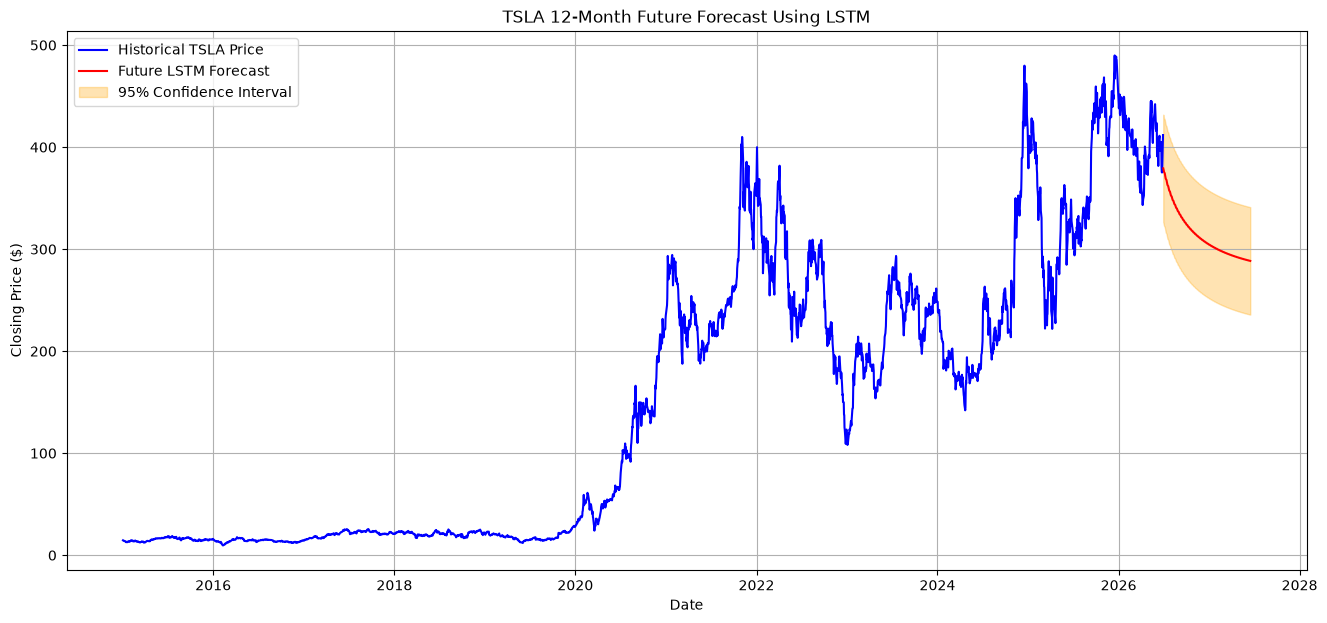

Starting Forecast Price: 379.18
Ending Forecast Price: 288.51
Expected Change (%): -23.91

Confidence Interval Width
Beginning: 105.32
End: 105.32


In [28]:
# ==========================================================
# TASK 3: FUTURE FORECAST USING LSTM
# ==========================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# ==========================================================
# 1. Prepare Data for Forecasting
# ==========================================================


# Make sure Close price is numeric

tsla["Close"] = pd.to_numeric(
    tsla["Close"],
    errors="coerce"
)


prices = tsla[["Close"]].astype(float)



# Scale full dataset using the training scaler

scaled_all = scaler.transform(
    prices
)



# ==========================================================
# 2. Generate Future Predictions
# ==========================================================


future_days = 252

window = 60



# Last 60 trading days

last_sequence = scaled_all[-window:]



current_sequence = torch.tensor(
    last_sequence,
    dtype=torch.float32
)



future_predictions_scaled = []



lstm_model.eval()



with torch.no_grad():

    for i in range(future_days):


        # Add batch dimension

        input_data = current_sequence.unsqueeze(0)



        prediction = lstm_model(
            input_data
        )



        future_predictions_scaled.append(
            prediction.item()
        )



        # Move window forward

        current_sequence = torch.cat(
            (
                current_sequence[1:],
                prediction
            ),
            dim=0
        )





# Convert scaled predictions back to prices

future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled)
    .reshape(-1,1)
).flatten()





# ==========================================================
# 3. Create Future Dates
# ==========================================================


future_dates = pd.date_range(

    start=tsla.index[-1] + pd.Timedelta(days=1),

    periods=future_days,

    freq="B"

)





# ==========================================================
# 4. Create Forecast DataFrame
# ==========================================================


future_forecast = pd.DataFrame(

    {
        "Forecast": future_predictions
    },

    index=future_dates

)



display(
    future_forecast.head()
)





# ==========================================================
# 5. Confidence Interval
# ==========================================================


# Use your Task 2 LSTM RMSE

lstm_rmse = 26.867926939882707



future_forecast["Lower_CI"] = (

    future_forecast["Forecast"]

    -
    
    1.96 * lstm_rmse

)



future_forecast["Upper_CI"] = (

    future_forecast["Forecast"]

    +

    1.96 * lstm_rmse

)





# ==========================================================
# 6. Plot Historical + Future Forecast
# ==========================================================


plt.figure(
    figsize=(16,7)
)



# Historical price

plt.plot(

    tsla.index,

    tsla["Close"],

    label="Historical TSLA Price",

    color="blue"

)



# Future forecast

plt.plot(

    future_forecast.index,

    future_forecast["Forecast"],

    label="Future LSTM Forecast",

    color="red"

)



# Confidence interval

plt.fill_between(

    future_forecast.index,

    future_forecast["Lower_CI"],

    future_forecast["Upper_CI"],

    color="orange",

    alpha=0.3,

    label="95% Confidence Interval"

)



plt.title(
    "TSLA 12-Month Future Forecast Using LSTM"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Closing Price ($)"
)


plt.legend()

plt.grid()

plt.show()





# ==========================================================
# 7. Forecast Trend Analysis
# ==========================================================


start_price = future_forecast["Forecast"].iloc[0]


end_price = future_forecast["Forecast"].iloc[-1]



percentage_change = (

    (end_price - start_price)

    /

    start_price

) * 100



print(
    "Starting Forecast Price:",
    round(start_price,2)
)


print(
    "Ending Forecast Price:",
    round(end_price,2)
)


print(
    "Expected Change (%):",
    round(percentage_change,2)
)





# ==========================================================
# 8. Confidence Interval Width
# ==========================================================


future_forecast["CI_width"] = (

    future_forecast["Upper_CI"]

    -

    future_forecast["Lower_CI"]

)



print("\nConfidence Interval Width")


print(
    "Beginning:",
    round(
        future_forecast["CI_width"].iloc[0],
        2
    )
)


print(
    "End:",
    round(
        future_forecast["CI_width"].iloc[-1],
        2
    )
)